### **Importing Data **

In [1]:
import os
import tensorflow as tf

# Local path (looks in the same folder your notebook is in)
tfrecord_path = './tfrecord'

# Checking for datasets in designated folder
print("Files in the folder:")
try:
    files = os.listdir(tfrecord_path)
    for file in files:
        print(file)
except FileNotFoundError:
    print(f"No folder found at: {tfrecord_path}")

Files in the folder:
train-00007-of-00008
train-00006-of-00008
test-00000-of-00001
val-00000-of-00001
train-00000-of-00008
train-00001-of-00008
train-00004-of-00008
train-00005-of-00008
train-00003-of-00008
train-00002-of-00008


In [2]:
def parse_tfrecord_fn(example):
    feature_description = {
        'global_view': tf.io.FixedLenFeature([2001], tf.float32),
        'local_view': tf.io.FixedLenFeature([201], tf.float32),
        'av_training_set': tf.io.FixedLenFeature([], tf.string)
    }
    
    parsed_features = tf.io.parse_single_example(example, feature_description)
    global_view = parsed_features['global_view']
    local_view = parsed_features['local_view']

    raw_label = parsed_features['av_training_set']
    is_planet = tf.cast(tf.equal(raw_label, b'PC'), tf.float32)
    label = tf.reshape(is_planet, [1])

    return {'global_view': global_view, 'local_view': local_view}, label

print("Parsing function ready")

Parsing function ready


In [3]:
# Creating lists of the exact file paths for each category
train_files = [os.path.join(tfrecord_path, f) for f in os.listdir(tfrecord_path) if 'train' in f]
val_files = [os.path.join(tfrecord_path, f) for f in os.listdir(tfrecord_path) if 'val' in f]
test_files = [os.path.join(tfrecord_path, f) for f in os.listdir(tfrecord_path) if 'test' in f]

# Telling TensorFlow to read the raw binary data from these files
raw_train_dataset = tf.data.TFRecordDataset(train_files)
raw_val_dataset = tf.data.TFRecordDataset(val_files)
raw_test_dataset = tf.data.TFRecordDataset(test_files)

# Applying our parsing function and group the data into batches
batch_size = 64

train_dataset = raw_train_dataset.map(parse_tfrecord_fn).batch(batch_size).repeat()
val_dataset = raw_val_dataset.map(parse_tfrecord_fn).batch(batch_size)
test_dataset = raw_test_dataset.map(parse_tfrecord_fn).batch(batch_size)

print("Datasets are loaded, parsed, and batched")

Datasets are loaded, parsed, and batched


In [4]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Concatenate, Dense
from tensorflow.keras.models import Model

def build_exoplanet_cnn():
    global_input = Input(shape=(2001, 1), name='global_view')
    local_input = Input(shape=(201, 1), name='local_view')

    x_global = Conv1D(filters=16, kernel_size=5, activation='relu')(global_input)
    x_global = MaxPooling1D(pool_size=2, strides=2)(x_global)
    x_global = Conv1D(filters=32, kernel_size=5, activation='relu')(x_global)
    x_global = MaxPooling1D(pool_size=2, strides=2)(x_global)
    x_global = Flatten()(x_global)

    x_local = Conv1D(filters=16, kernel_size=5, activation='relu')(local_input)
    x_local = MaxPooling1D(pool_size=2, strides=2)(x_local)
    x_local = Conv1D(filters=32, kernel_size=5, activation='relu')(x_local)
    x_local = MaxPooling1D(pool_size=2, strides=2)(x_local)
    x_local = Flatten()(x_local)

    merged = Concatenate()([x_global, x_local])
    dense = Dense(64, activation='relu')(merged)
    output = Dense(1, activation='sigmoid', name='label')(dense)

    model = Model(inputs=[global_input, local_input], outputs=output)
    return model

test_model = build_exoplanet_cnn()
test_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ global_view         │ (None, 2001, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_view          │ (None, 201, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1997, 16)  │         96 │ global_view[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 197, 16)   │         96 │ local_view[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 998, 16)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 98, 16)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 994, 32)   │      2,592 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 94, 32)    │      2,592 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 497, 32)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 47, 32)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 15904)     │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1504)      │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 17408)     │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │  1,114,176 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (Dense)       │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,119,617 (4.27 MB)

 Trainable params: 1,119,617 (4.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam  # importing optimizer
trained_models = []
print("Starting Ensemble Training locally on Mac with 0.00001 Learning Rate...")

for i in range(10): 
    print(f"\n--- Training Model Copy {i+1} of 10 ---")
    
    early_stopper = EarlyStopping(
        monitor='val_loss',     
        patience=12,             
        restore_best_weights=True,
        verbose=1
    )
    
    current_model = build_exoplanet_cnn()
    
    # changing learning rate in optimizer
    custom_adam = Adam(learning_rate=0.00001)
    current_model.compile(optimizer=custom_adam, loss='binary_crossentropy', metrics=['accuracy'])
    
    history = current_model.fit(
        train_dataset, 
        validation_data=val_dataset, 
        epochs=100,                  # increasing epoch to 100
        steps_per_epoch=197,
        callbacks=[early_stopper],
        verbose=1 
    ) 
    
    trained_models.append(current_model)
    
    save_path = f'./model_copy_{i+1}.keras'
    current_model.save(save_path)
    
    best_epoch = early_stopper.best_epoch + 1 if early_stopper.best_epoch is not None else "Final"
    print(f" Model {i+1} training complete! Optimal weights retained from Epoch {best_epoch}.")

print("\n All 10 models have successfully finished training!")

Starting Ensemble Training locally on Mac with 0.00001 Learning Rate...

--- Training Model Copy 1 of 10 ---
Epoch 1/100


/Users/adityasharma/Desktop/Exoplanets/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 20/197 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6406 - loss: 0.6535

I0000 00:00:1787229493.326265  849347 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7576 - loss: 0.5131 - val_accuracy: 0.7745 - val_loss: 0.4760
Epoch 2/100
 19/197 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7615 - loss: 0.4871

/Users/adityasharma/Desktop/Exoplanets/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7696 - loss: 0.4622 - val_accuracy: 0.7713 - val_loss: 0.4404
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7567 - loss: 0.4246 - val_accuracy: 0.7560 - val_loss: 0.4005
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7766 - loss: 0.3860 - val_accuracy: 0.7897 - val_loss: 0.3637
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8051 - loss: 0.3534 - val_accuracy: 0.8189 - val_loss: 0.3350
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8314 - loss: 0.3280 - val_accuracy: 0.8412 - val_loss: 0.3124
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8573 - loss: 0.3073 - val_accuracy: 0.8679 - val_loss: 0.2935
Epoch 8/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8805 - loss: 0.2894 - val_accuracy: 0.8926 - val_loss: 0.2750
Epoch 9/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8963 - loss: 0.2707 - val_accuracy: 0.906

Loading trained models from disk...
Gathering predictions from all 10 models on the Test Data...
Model 1 predicting...
Model 2 predicting...


/Users/adityasharma/Desktop/Exoplanets/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Model 3 predicting...
Model 4 predicting...
Model 5 predicting...
Model 6 predicting...
Model 7 predicting...
Model 8 predicting...
Model 9 predicting...
Model 10 predicting...

--- FINAL ENSEMBLE TEST SCORES ---
Accuracy:  93.96%
Precision: 86.91%
Recall:    86.67%



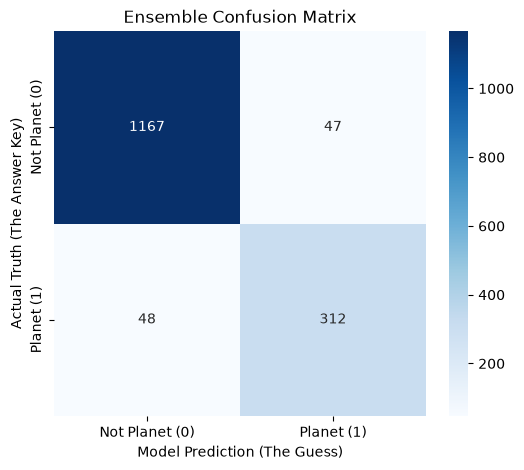

In [6]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Extracting the actual true answers from the test dataset
true_labels = []
for data, label in test_dataset:
    true_labels.extend(label.numpy())
true_labels = np.array(true_labels)

# Loading the 10 models from your Mac's hard drive
trained_models = []
print("Loading trained models from disk...")
for i in range(1, 11):
    trained_models.append(tf.keras.models.load_model(f'./model_copy_{i}.keras'))

# Asking all 10 models to take the final blind exam
all_predictions = []
print("Gathering predictions from all 10 models on the Test Data...")

for i, model in enumerate(trained_models):
    print(f"Model {i+1} predicting...")
    predictions = model.predict(test_dataset, verbose=0)
    all_predictions.append(predictions)

# The Ensemble Work: Average the predictions
averaged_probabilities = np.mean(all_predictions, axis=0)
final_predictions = (averaged_probabilities > 0.5).astype(float)

# Calculate and Plot Metrics
acc = accuracy_score(true_labels, final_predictions)
prec = precision_score(true_labels, final_predictions)
rec = recall_score(true_labels, final_predictions)

print("\n--- FINAL ENSEMBLE TEST SCORES ---")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%\n")

cm = confusion_matrix(true_labels, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Planet (0)', 'Planet (1)'],
            yticklabels=['Not Planet (0)', 'Planet (1)'])
plt.ylabel('Actual Truth (The Answer Key)')
plt.xlabel('Model Prediction (The Guess)')
plt.title('Ensemble Confusion Matrix')
plt.show()

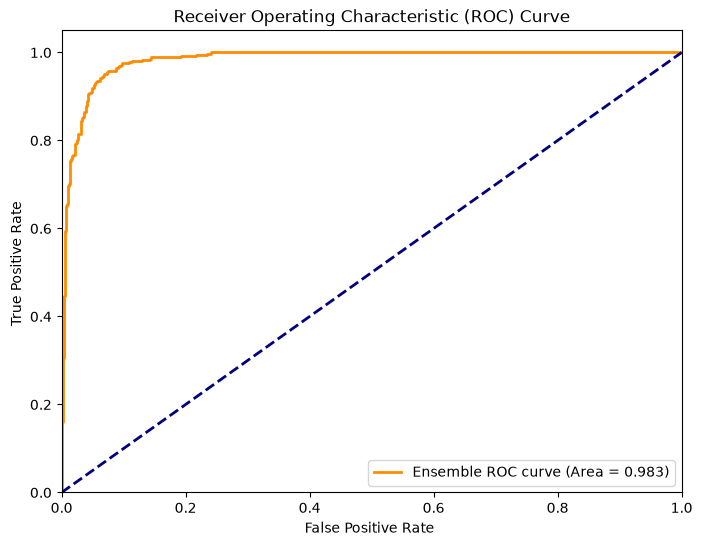

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(true_labels, averaged_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Ensemble ROC curve (Area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate ')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Extracting brain cell patterns...
Calculating 2D geometry with t-SNE (this may take a minute)...


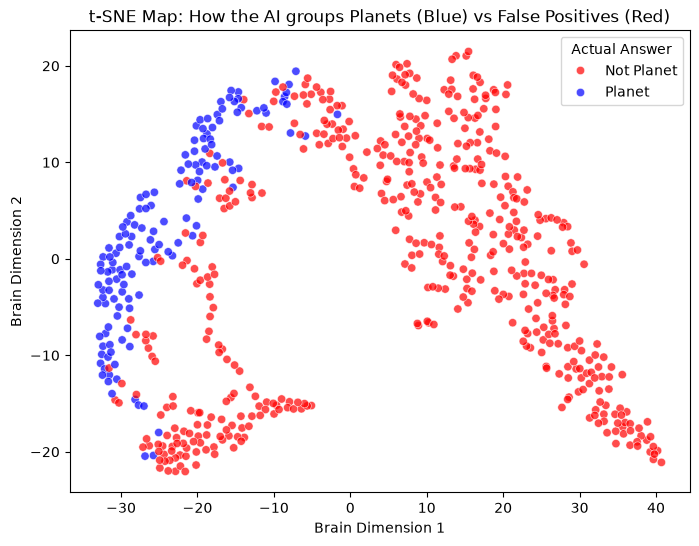

In [9]:
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Build a "Sub-Model" that stops at the 64-neuron Dense layer
best_model = trained_models[0]

# Automatically find the correct 64-neuron dense layer
dense_layer = None
for layer in reversed(best_model.layers):
    if 'dense' in layer.name.lower() and layer.units == 64:
        dense_layer = layer
        break


if dense_layer is None:
    dense_layer = best_model.layers[-2]

brain_model = Model(inputs=best_model.input, outputs=dense_layer.output)

# Feed 640 stars into the sub-model to map its brain
test_features = []
test_labels_list = []

print("Extracting brain cell patterns...")

# Ensureing dataset is parsed
try:
    sample_batch = next(iter(test_dataset.take(1)))
    if isinstance(sample_batch[0], tf.Tensor) and sample_batch[0].dtype == tf.string:
        safe_dataset = test_dataset.map(parse_tfrecord_fn).batch(64)
    else:
        safe_dataset = test_dataset
except Exception:
    safe_dataset = test_dataset.map(parse_tfrecord_fn).batch(64)

# Loop through 10 batches (640 stars)
for batch_data, batch_labels in safe_dataset.take(10):

    # Re-map the dictionary keys to ensure they match Keras expectations
    if isinstance(batch_data, dict):
        fixed_batch = {
            'global_view': batch_data.get('global_input', batch_data.get('global_view')),
            'local_view': batch_data.get('local_input', batch_data.get('local_view'))
        }
    else:
        fixed_batch = batch_data

    features = brain_model.predict(fixed_batch, verbose=0)
    test_features.extend(features)
    test_labels_list.extend(batch_labels.numpy())

test_features = np.array(test_features)
test_labels_list = np.array(test_labels_list)

# Calculating the 2D geometry with t-SNE
print("Calculating 2D geometry with t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(test_features)

# Ploting the Brain Map
plt.figure(figsize=(8, 6))

# Flattening the arrays to strictly 1D so Seaborn doesn't crash
x_coords = np.ravel(tsne_results[:, 0])
y_coords = np.ravel(tsne_results[:, 1])
flat_labels = np.ravel(test_labels_list)

sns.scatterplot(
    x=x_coords,
    y=y_coords,
    hue=flat_labels,
    palette=['red', 'blue'],
    alpha=0.7
)

plt.title("t-SNE Map: How the AI groups Planets (Blue) vs False Positives (Red)")
plt.xlabel("Brain Dimension 1")
plt.ylabel("Brain Dimension 2")

# Legends
handles, previous_labels = plt.gca().get_legend_handles_labels()
if handles:
    plt.legend(handles=handles, labels=["Not Planet", "Planet"], title="Actual Answer")

plt.show()

Preparing the 100% Flipped Universal Dataset...
Testing the ensemble on 15737 reversed stars...
Model 1 predicting...


/Users/adityasharma/Desktop/Exoplanets/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Model 2 predicting...
Model 3 predicting...
Model 4 predicting...
Model 5 predicting...
Model 6 predicting...
Model 7 predicting...
Model 8 predicting...
Model 9 predicting...
Model 10 predicting...

--- 100% FLIPPED UNIVERSAL TEST SCORES ---
Accuracy:  93.84%
Precision: 85.99%
Recall:    87.28%



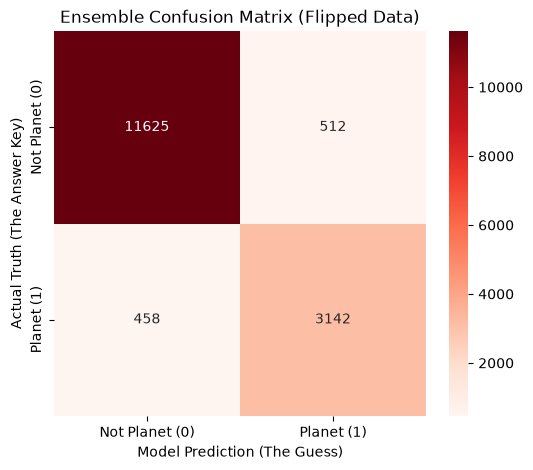

In [10]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Combining ALL data files into one massive list
all_files = train_files + val_files + test_files
raw_all_dataset = tf.data.TFRecordDataset(all_files)

# Defining the 100% guaranteed horizontal flip
def force_flip_lightcurves(features, label):
    # No random chance here. We flip every single array 100% of the time.
    features['global_view'] = tf.reverse(features['global_view'], axis=[0])
    features['local_view'] = tf.reverse(features['local_view'], axis=[0])
    return features, label

# Parse, Flip, and Batch the Universal Dataset
print("Preparing the 100% Flipped Universal Dataset...")
flipped_dataset = raw_all_dataset.map(parse_tfrecord_fn).map(force_flip_lightcurves).batch(batch_size)

# Extracting the True Answer Key
true_labels_flipped = []
for data, label in flipped_dataset:
    true_labels_flipped.extend(label.numpy())
true_labels_flipped = np.array(true_labels_flipped)

# Administer the Blind Exam to all 10 Models
all_flipped_predictions = []
print(f"Testing the ensemble on {len(true_labels_flipped)} reversed stars...")

for i, model in enumerate(trained_models):
    print(f"Model {i+1} predicting...")
    # Get predictions for the flipped data
    predictions = model.predict(flipped_dataset, verbose=0)
    all_flipped_predictions.append(predictions)

# Ensemble Voting (Average the probabilities)
averaged_flipped_probabilities = np.mean(all_flipped_predictions, axis=0)
final_flipped_predictions = (averaged_flipped_probabilities > 0.5).astype(float)

# Calculate the Final Grades
acc = accuracy_score(true_labels_flipped, final_flipped_predictions)
prec = precision_score(true_labels_flipped, final_flipped_predictions)
rec = recall_score(true_labels_flipped, final_flipped_predictions)

print("\n--- 100% FLIPPED UNIVERSAL TEST SCORES ---")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%\n")

# Plot the Confusion Matrix
cm = confusion_matrix(true_labels_flipped, final_flipped_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', # Changed to Red to signify flipped data
            xticklabels=['Not Planet (0)', 'Planet (1)'],
            yticklabels=['Not Planet (0)', 'Planet (1)'])
plt.ylabel('Actual Truth (The Answer Key)')
plt.xlabel('Model Prediction (The Guess)')
plt.title('Ensemble Confusion Matrix (Flipped Data)')
plt.show()

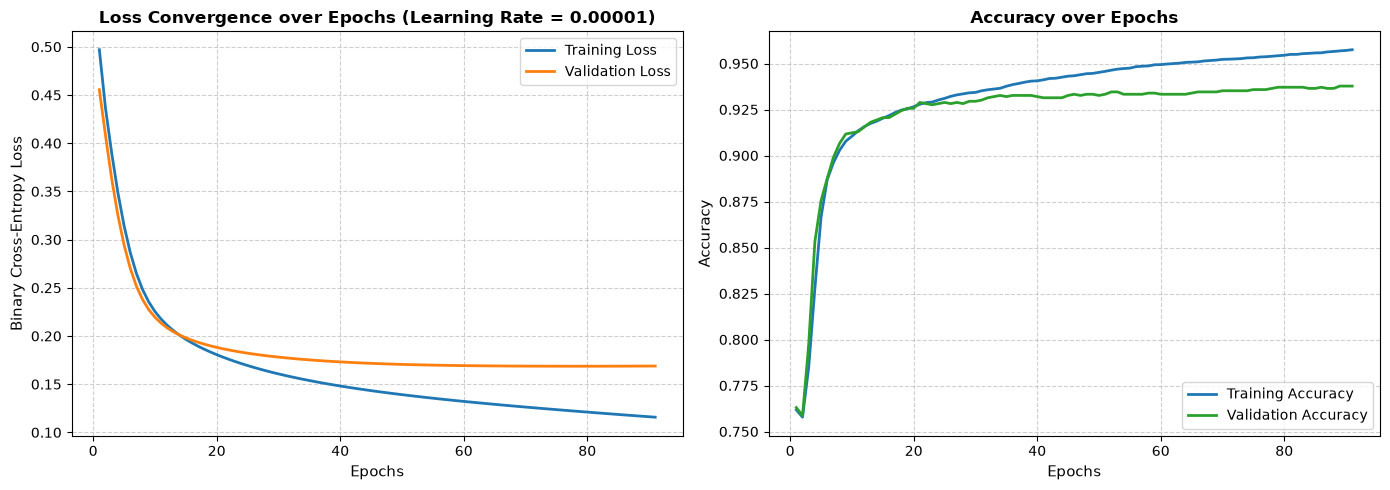

In [11]:
import matplotlib.pyplot as plt

# Check if 'history' is available from your training loop
if 'history' in locals():
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(14, 5))

    # --- Plot 1: Loss Convergence ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history['loss'], label='Training Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
    plt.title('Loss Convergence over Epochs (Learning Rate = 0.00001)', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Binary Cross-Entropy Loss', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10)

    # --- Plot 2: Accuracy Convergence ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='#2ca02c', lw=2)
    plt.title('Accuracy over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Run your training loop to generate the history object first.")

PLOTS TO SHOW

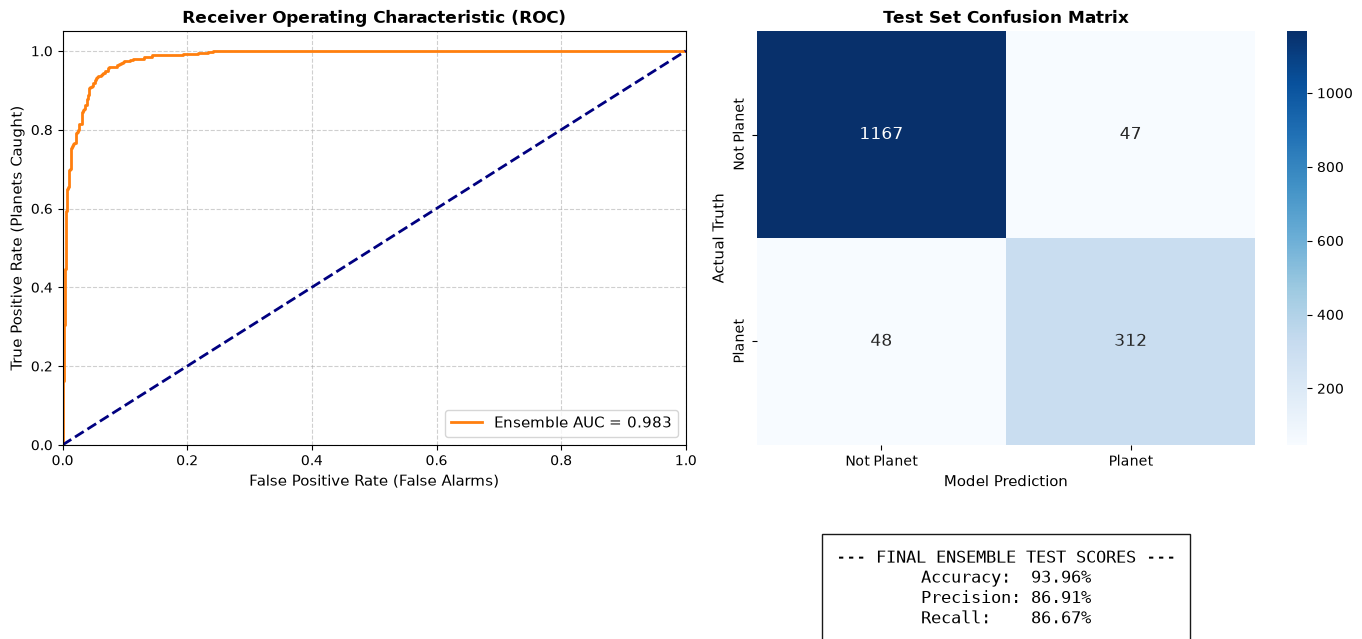

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the metrics for the text box
test_acc = accuracy_score(true_labels, final_predictions)
test_prec = precision_score(true_labels, final_predictions)
test_rec = recall_score(true_labels, final_predictions)

# Calculate ROC and CM math
fpr, tpr, thresholds = roc_curve(true_labels, averaged_probabilities)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(true_labels, final_predictions)

# --- Create a 1x2 Figure (Made slightly taller to fit text) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color='#ff7f0e', lw=2, label=f'Ensemble AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (False Alarms)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Planets Caught)', fontsize=11)
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Planet', 'Planet'],
            yticklabels=['Not Planet', 'Planet'],
            annot_kws={"size": 12})
axes[1].set_ylabel('Actual Truth', fontsize=11)
axes[1].set_xlabel('Model Prediction', fontsize=11)
axes[1].set_title('Test Set Confusion Matrix', fontsize=12, fontweight='bold')

# --- NEW: Add the terminal-style text box below the Confusion Matrix ---
metrics_text = (f"--- FINAL ENSEMBLE TEST SCORES ---\n"
                f"Accuracy:  {test_acc * 100:.2f}%\n"
                f"Precision: {test_prec * 100:.2f}%\n"
                f"Recall:    {test_rec * 100:.2f}%")

axes[1].text(0.5, -0.25, metrics_text, ha='center', va='top', transform=axes[1].transAxes, 
             fontsize=12, family='monospace', 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=10))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25) # Shove the graphs up slightly to make room for text
plt.show()

Preparing the 100% Flipped Universal Dataset...
Testing the ensemble on 15737 reversed stars...
Model 1 predicting...


/Users/adityasharma/Desktop/Exoplanets/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Model 2 predicting...
Model 3 predicting...
Model 4 predicting...
Model 5 predicting...
Model 6 predicting...
Model 7 predicting...
Model 8 predicting...
Model 9 predicting...
Model 10 predicting...

--- 100% FLIPPED UNIVERSAL TEST SCORES ---
Accuracy:  93.84%
Precision: 85.99%
Recall:    87.28%



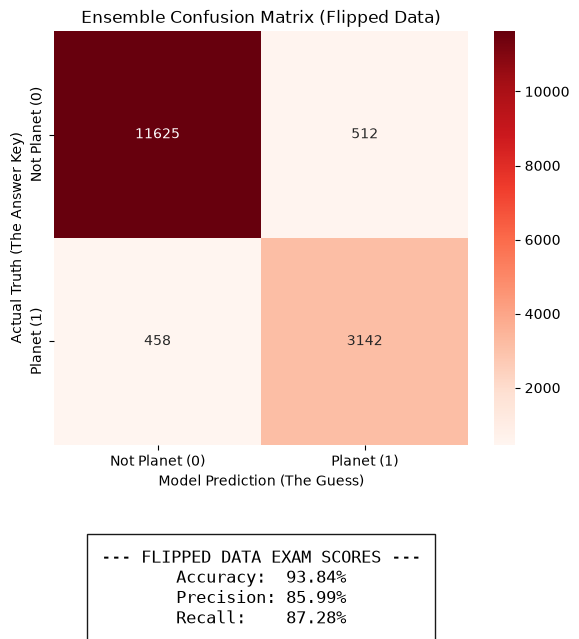

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Combining ALL data files into one massive list
all_files = train_files + val_files + test_files
raw_all_dataset = tf.data.TFRecordDataset(all_files)

# Defining the 100% guaranteed horizontal flip
def force_flip_lightcurves(features, label):
    # No random chance here. We flip every single array 100% of the time.
    features['global_view'] = tf.reverse(features['global_view'], axis=[0])
    features['local_view'] = tf.reverse(features['local_view'], axis=[0])
    return features, label

# Parse, Flip, and Batch the Universal Dataset
print("Preparing the 100% Flipped Universal Dataset...")
flipped_dataset = raw_all_dataset.map(parse_tfrecord_fn).map(force_flip_lightcurves).batch(batch_size)

# Extracting the True Answer Key
true_labels_flipped = []
for data, label in flipped_dataset:
    true_labels_flipped.extend(label.numpy())
true_labels_flipped = np.array(true_labels_flipped)

# Administer the Blind Exam to all 10 Models
all_flipped_predictions = []
print(f"Testing the ensemble on {len(true_labels_flipped)} reversed stars...")

for i, model in enumerate(trained_models):
    print(f"Model {i+1} predicting...")
    # Get predictions for the flipped data
    predictions = model.predict(flipped_dataset, verbose=0)
    all_flipped_predictions.append(predictions)

# Ensemble Voting (Average the probabilities)
averaged_flipped_probabilities = np.mean(all_flipped_predictions, axis=0)
final_flipped_predictions = (averaged_flipped_probabilities > 0.5).astype(float)

# Calculate the Final Grades
acc = accuracy_score(true_labels_flipped, final_flipped_predictions)
prec = precision_score(true_labels_flipped, final_flipped_predictions)
rec = recall_score(true_labels_flipped, final_flipped_predictions)

print("\n--- 100% FLIPPED UNIVERSAL TEST SCORES ---")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%\n")


# Plot the Confusion Matrix with Embedded Text
cm_flipped = confusion_matrix(true_labels_flipped, final_flipped_predictions)

# Make figure slightly taller
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Not Planet (0)', 'Planet (1)'],
            yticklabels=['Not Planet (0)', 'Planet (1)'])
ax.set_ylabel('Actual Truth (The Answer Key)')
ax.set_xlabel('Model Prediction (The Guess)')
ax.set_title('Ensemble Confusion Matrix (Flipped Data)')

# adding dta down to graph
flipped_metrics_text = (f"--- FLIPPED DATA EXAM SCORES ---\n"
                        f"Accuracy:  {acc * 100:.2f}%\n"
                        f"Precision: {prec * 100:.2f}%\n"
                        f"Recall:    {rec * 100:.2f}%")

ax.text(0.5, -0.25, flipped_metrics_text, ha='center', va='top', transform=ax.transAxes, 
        fontsize=12, family='monospace', 
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=10))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25) # Make room for text
plt.show()